# Distributions

Interesting sources: 
- https://app.datacamp.com/learn/courses/foundations-of-probability-in-python

In [13]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Uniform distribution

## Rolling a 6-sided die

![](https://wherethewindsblow.com/wp-content/uploads/2023/06/JUMBO-Six-sided-white-dice.jpg)

We are simulating the process of rolling a standard six-sided die. Each roll produces a random integer between 1 and 6, with all outcomes being equally likely. By generating multiple samples within this range, we can observe how the distribution of results begins to resemble a uniform distribution as the number of rolls increases.

In [1]:
minValue = 1 #  
maxValue = 6 # Maximum value of the dice
numberOfSamples = 6 # Increase number to show that it converges to a uniform distribution

Now we simulate rolling the die ```numberOfSamples``` times:
If you rerun the script you can see that the values change, just like a 'real' die.

In [2]:
import pandas as pd 
import numpy as np

results = pd.Series( np.random.randint(low=minValue, high=maxValue + 1, size=numberOfSamples) )
results

0    5
1    1
2    3
3    4
4    6
5    4
dtype: int32

<Axes: >

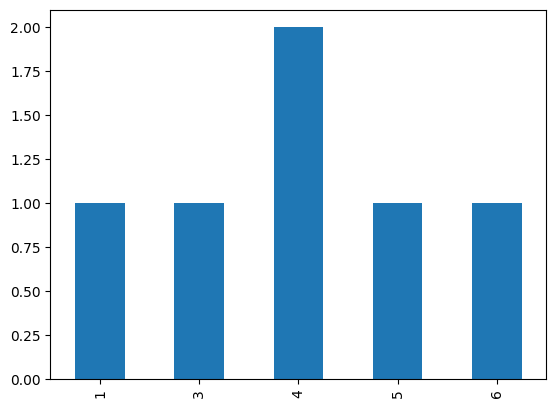

In [3]:
results.value_counts().sort_index().plot(kind='bar')

## Normal distribution

### Sampling from the average length of  a full-grown citizen in the Netherlands.

Mean = Median = Mode (all located in the center)

Symmetrical around the mean

Approximately:

- 68% of the values fall within 1 standard deviation of the mean
- 95% within 2 standard deviations
- 99.7% within 3 standard deviations

(This is known as the empirical rule or 68-95-99.7 rule)

In [4]:
averageLength = 174.25 # Average length of a person in cm
stdLength = 8 # Standard deviation of the length of a person in cm
numberOfPeopleToSample = 3000 # Play with these values to show the impact on the histogram

In [5]:
randomLengths = pd.Series( np.random.normal(averageLength, stdLength, numberOfPeopleToSample) )
randomLengths.head()

0    174.603239
1    187.827437
2    181.305647
3    180.793786
4    188.529030
dtype: float64

<Axes: ylabel='Frequency'>

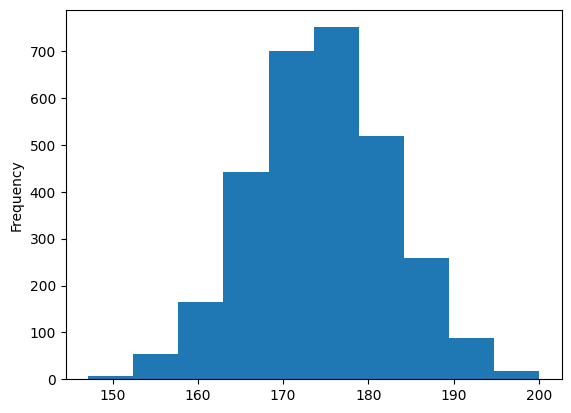

In [6]:
randomLengths.plot(kind='hist', bins=10)

![](https://upload.wikimedia.org/wikipedia/commons/8/8c/Standard_deviation_diagram.svg 'Normal distribution')

### Examples of normal distribution in real life
- https://studiousguy.com/real-life-examples-normal-distribution/
- https://galtonboard.com/probabilityexamplesinlife

### Central limit theorem

**What is the Central Limit Theorem?**
In simple terms:

If you take many random samples of a certain size from any population, and calculate the mean of each sample, then the distribution of those sample means will:
- Be approximately normal (bell-shaped)
- Have the same average as the original population
- Have a smaller spread (standard deviation gets smaller as sample size increases)
- Even if the original data is not normally distributed!

**Why is this useful?**
Because it lets us:
- Use normal distribution tools (like confidence intervals) on data that isn't normal
- Make predictions and inferences about population averages
- Justify why the mean is a reliable estimate with large samples



In [7]:
sampleMeans = []
sampleSize = 100
sampleMeansSize = 10000

for i in range(sampleMeansSize):
    randomLengths = pd.Series( np.random.normal(averageLength, stdLength, sampleSize) ) 
    sampleMeans.append(randomLengths.mean()) 

In [8]:
sampleMeans

[np.float64(173.21801394078244),
 np.float64(176.1217069562216),
 np.float64(173.77371687378076),
 np.float64(174.71272625344326),
 np.float64(174.09786381033683),
 np.float64(175.82581956387122),
 np.float64(174.40187577327083),
 np.float64(173.68008582791555),
 np.float64(175.0984792056068),
 np.float64(174.753308695961),
 np.float64(174.77092986093578),
 np.float64(175.40294860741244),
 np.float64(174.30518298071524),
 np.float64(173.9638905198466),
 np.float64(174.20142542149432),
 np.float64(174.29994334587823),
 np.float64(172.9491125458706),
 np.float64(175.0136798635592),
 np.float64(173.96809262910057),
 np.float64(174.56078833543725),
 np.float64(174.6930665555439),
 np.float64(173.3551059991448),
 np.float64(173.41769761760355),
 np.float64(174.53960002755113),
 np.float64(174.29483754360695),
 np.float64(173.89289268114263),
 np.float64(174.20890227336565),
 np.float64(174.46472756686472),
 np.float64(173.7027518172623),
 np.float64(174.37177790756272),
 np.float64(173.5439

<Axes: ylabel='Frequency'>

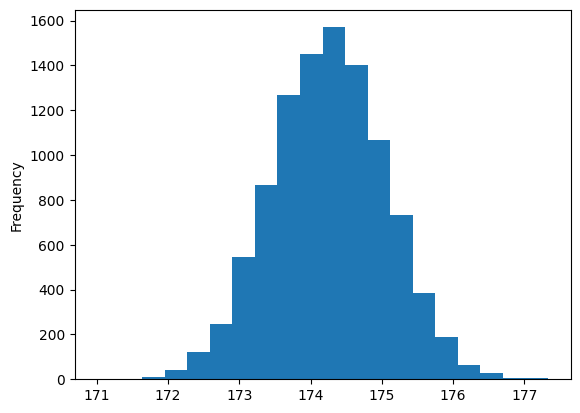

In [9]:
pd.Series(sampleMeans).plot(kind='hist', bins = 20)

In [10]:
sampleMeans = []
sampleSize = 100
sampleMeansSize = 10000

for i in range(sampleMeansSize):
    randomRolls = pd.Series( np.random.randint(low=minValue, high=maxValue + 1, size=sampleSize) )
    sampleMeans.append(randomRolls.mean())

<Axes: ylabel='Frequency'>

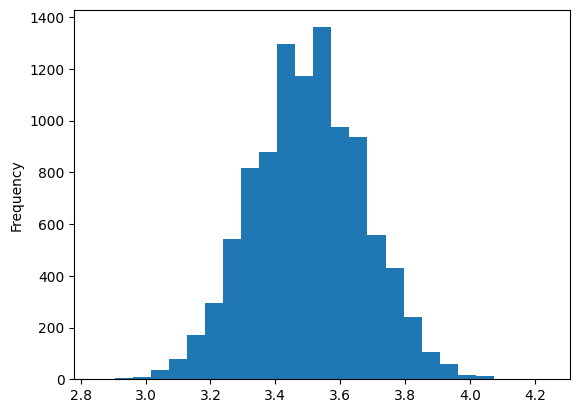

In [11]:
pd.Series(sampleMeans).plot(kind='hist', bins = 25)

### Confidence interval

**What is a Confidence Interval?**
A confidence interval is a range of values that we believe is likely to contain the true population parameter (like the mean or proportion), based on a sample.

Usually, we talk about the **mean**, so let’s focus on that:

A 95% confidence interval for the mean says:
“We are 95% confident that the true population mean lies within this range.”


![](https://datatab.net/assets/tutorial/confidence_interval.png)

![](https://datatab.net/assets/tutorial/Confidence_interval_formula.png)

So let's reconsider one sample. Based on this one sample, what can we say about the mean of the underlying population?

In [12]:
import scipy.stats as st
confidence = 0.95
st.t.interval(confidence, len(randomLengths)-1, loc=randomLengths.mean(), scale=st.sem(randomLengths))

(np.float64(171.12823940697092), np.float64(174.2259607265052))

And how about rolling a dice?

In [18]:
import scipy.stats as st
confidence = 0.95
st.t.interval(confidence, len(randomRolls)-1, loc=randomRolls.mean(), scale=st.sem(randomRolls))

(np.float64(2.929152899519573), np.float64(3.5908471004804268))

Let's apply this to the iris dataset. What is the 95% confidence interval of the sepal_length? Meaning, let's calculate the interval that contains the real mean sepal length with 95% confidence.

In [14]:
import seaborn as sns
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [19]:
import scipy.stats as st
confidence = 0.98
st.t.interval(confidence, len(iris)-1, loc=iris['sepal_length'].mean(), scale=st.sem(iris['sepal_length']))

(np.float64(5.684336202790978), np.float64(6.00233046387569))

### Portfolio assignment 7
15 min: Look at the histogram of at least 2 columns with numerical data in the dataset that you chose in portfolio assignment 4. Do you recognise the distribution? Does it look like a uniform or normal distribution or something else? If it doesn't look like a uniform or normal distribution, take a quick look here to see if you can find the distribution shape: https://www.itl.nist.gov/div898/handbook/eda/section3/eda366.htm


![](https://i.imgur.com/0v1CGNV.png)<br>
Findings: ...<br>

### Portfolio assignment 8
15 min: 
- Calculate the 90%, 95%, 99% and 99.99% confidence interval for at least 2 columns with numerical data in the dataset that you chose in portfolio assignment 4. Do you see the impact the confidence has on the interval?
- Now calculate the 95% confidence interval again but use only the first 10% of your rows. Compare this interval to the previous 95% confidence interval you calculated. Do you see the impact of having less data?

![](https://i.imgur.com/0v1CGNV.png)<br>
Assumptions: ...<br>
Findings: ...<br>